# Smart Outcome  predicter

### Task 6: Identify Features and Target Variables

There are two Machine Learning tasks.

### Classification
Target Variable:
- completion_status

### Regression
Target Variable:
- final_score

The remaining columns are used as input features.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
df=pd.read_csv('Smart Outcome Predictor Dataset.csv')
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [2]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5200
Columns : 19


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   object 
 3   device_type            5200 non-null   object 
 4   education_background   5200 non-null   object 
 5   course_level           5200 non-null   object 
 6   course_category        5200 non-null   object 
 7   course_start_date      5200 non-null   object 
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_

In [4]:
df.columns

Index(['student_id', 'age', 'country_region', 'device_type',
       'education_background', 'course_level', 'course_category',
       'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours',
       'videos_watched', 'quiz_attempts', 'assignments_submitted',
       'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status',
       'final_score'],
      dtype='object')

In [5]:
X = df.drop(["completion_status","final_score"], axis=1)

y_class = df["completion_status"]

y_reg = df["final_score"]

print("Number of Features :", X.shape[1])

Number of Features : 17


### Task 7: Train-Test Split

In [6]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Classification Train Shape :", X_train_cls.shape)
print("Classification Test Shape :", X_test_cls.shape)

Classification Train Shape : (4160, 17)
Classification Test Shape : (1040, 17)


In [7]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression Train Shape :", X_train_reg.shape)
print("Regression Test Shape :", X_test_reg.shape)

Regression Train Shape : (4160, 17)
Regression Test Shape : (1040, 17)


### Task 8: Basic Preprocessing

In [8]:
df.dtypes

student_id                 int64
age                        int64
country_region            object
device_type               object
education_background      object
course_level              object
course_category           object
course_start_date         object
week_of_year               int64
sessions                   int64
time_spent_hours         float64
videos_watched             int64
quiz_attempts              int64
assignments_submitted      int64
forum_posts                int64
avg_quiz_score           float64
attendance_rate          float64
completion_status          int64
final_score              float64
dtype: object

In [9]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns")
print(categorical_cols)

print()

print("Numerical Columns")
print(numerical_cols)

Categorical Columns
['country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date']

Numerical Columns
['student_id', 'age', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']


In [10]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", StandardScaler(), numerical_cols),

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)

    ]

)

In [11]:
X_train_cls_processed = preprocessor.fit_transform(X_train_cls)

X_test_cls_processed = preprocessor.transform(X_test_cls)

print(X_train_cls_processed.shape)

print(X_test_cls_processed.shape)

(4160, 396)
(1040, 396)


In [12]:
X_train_reg_processed = preprocessor.fit_transform(X_train_reg)

X_test_reg_processed = preprocessor.transform(X_test_reg)

print(X_train_reg_processed.shape)

print(X_test_reg_processed.shape)

(4160, 396)
(1040, 396)


In [13]:
# Convert to datetime
df["course_start_date"] = pd.to_datetime(df["course_start_date"])

# Extract features
df["course_year"] = df["course_start_date"].dt.year
df["course_month"] = df["course_start_date"].dt.month
df["course_day"] = df["course_start_date"].dt.day
df["course_dayofweek"] = df["course_start_date"].dt.dayofweek

# Drop original date column
df.drop("course_start_date", axis=1, inplace=True)

# Part C: Bagging (Bootstrap Aggregating)

### Task 9: Bagging Classifier

Bagging (Bootstrap Aggregating) combines multiple Decision Trees trained on different bootstrap samples.

It reduces variance and improves prediction accuracy.

fill null values

In [14]:
print(df.isnull().sum())

student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
course_year                0
course_month               0
course_day                 0
course_dayofweek           0
dtype: int64


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train_cls_processed = preprocessor.fit_transform(X_train_cls)
X_test_cls_processed = preprocessor.transform(X_test_cls)

In [16]:
dt_classifier = DecisionTreeClassifier(random_state=42)

dt_classifier.fit(X_train_cls_processed, y_train_cls)

dt_pred = dt_classifier.predict(X_test_cls_processed)

dt_accuracy = accuracy_score(y_test_cls, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.6394230769230769


In [17]:
bag_classifier = BaggingClassifier(

    estimator=DecisionTreeClassifier(),

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

bag_classifier.fit(X_train_cls_processed, y_train_cls)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [18]:
bag_pred = bag_classifier.predict(X_test_cls_processed)

In [19]:
bag_accuracy = accuracy_score(y_test_cls, bag_pred)

print("Bagging Accuracy :", bag_accuracy)

Bagging Accuracy : 0.725


In [20]:
cm = confusion_matrix(y_test_cls, bag_pred)

print(cm)

[[537 113]
 [173 217]]


In [21]:
print(classification_report(y_test_cls, bag_pred))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       650
           1       0.66      0.56      0.60       390

    accuracy                           0.72      1040
   macro avg       0.71      0.69      0.70      1040
weighted avg       0.72      0.72      0.72      1040



In [22]:
import pandas as pd
import numpy as np

print("NaN in X_train_reg:")
print(pd.DataFrame(X_train_reg).isnull().sum())

print("\nNaN in X_test_reg:")
print(pd.DataFrame(X_test_reg).isnull().sum())



NaN in X_train_reg:
student_id                0
age                       0
country_region            0
device_type               0
education_background      0
course_level              0
course_category           0
course_start_date         0
week_of_year              0
sessions                  0
time_spent_hours         93
videos_watched            0
quiz_attempts             0
assignments_submitted     0
forum_posts               0
avg_quiz_score           67
attendance_rate          59
dtype: int64

NaN in X_test_reg:
student_id                0
age                       0
country_region            0
device_type               0
education_background      0
course_level              0
course_category           0
course_start_date         0
week_of_year              0
sessions                  0
time_spent_hours         19
videos_watched            0
quiz_attempts             0
assignments_submitted     0
forum_posts               0
avg_quiz_score           14
attendance_rate        

In [23]:
print("NaN after preprocessing (Train):",
      np.isnan(X_train_reg_processed.toarray()).sum()
      if hasattr(X_train_reg_processed, "toarray")
      else np.isnan(X_train_reg_processed).sum())

print("NaN after preprocessing (Test):",
      np.isnan(X_test_reg_processed.toarray()).sum()
      if hasattr(X_test_reg_processed, "toarray")
      else np.isnan(X_test_reg_processed).sum())

NaN after preprocessing (Train): 219
NaN after preprocessing (Test): 54


In [24]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
    
])
X_train_reg_processed = preprocessor.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor.transform(X_test_reg)

# Task 10: Bagging Regressor

Bagging Regressor combines predictions from multiple Decision Tree Regressors by averaging.

This reduces overfitting and improves prediction stability.

In [25]:
dt_regressor = DecisionTreeRegressor(random_state=42)

dt_regressor.fit(X_train_reg_processed, y_train_reg)

dt_reg_pred = dt_regressor.predict(X_test_reg_processed)

In [26]:
dt_mae = mean_absolute_error(y_test_reg, dt_reg_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test_reg, dt_reg_pred))

dt_r2 = r2_score(y_test_reg, dt_reg_pred)

print("Decision Tree Results")

print("MAE :", dt_mae)

print("RMSE :", dt_rmse)

print("R2 Score :", dt_r2)

Decision Tree Results
MAE : 11.055000000000001
RMSE : 13.846571361226522
R2 Score : -0.02616134824762084


In [27]:
bag_regressor = BaggingRegressor(

    estimator=DecisionTreeRegressor(),

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

bag_regressor.fit(X_train_reg_processed, y_train_reg)

,estimator,DecisionTreeRegressor()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [28]:
bag_reg_pred = bag_regressor.predict(X_test_reg_processed)

In [29]:
bag_mae = mean_absolute_error(y_test_reg, bag_reg_pred)

bag_rmse = np.sqrt(mean_squared_error(y_test_reg, bag_reg_pred))

bag_r2 = r2_score(y_test_reg, bag_reg_pred)

print("Bagging Regressor Results")

print("MAE :", bag_mae)

print("RMSE :", bag_rmse)

print("R2 Score :", bag_r2)

Bagging Regressor Results
MAE : 7.987297115384616
RMSE : 9.970811593625513
R2 Score : 0.467901327028054


## Task 11: Compare Bagging Results with Single Base Model

In [30]:
classification_results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Bagging Classifier"
    ],

    "Accuracy":[
        dt_accuracy,
        bag_accuracy
    ]

})

classification_results

,Model,Accuracy
0,Decision Tree,0.639423
1,Bagging Classifier,0.725000


In [31]:
regression_results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Bagging Regressor"
    ],

    "MAE":[
        dt_mae,
        bag_mae
    ],

    "RMSE":[
        dt_rmse,
        bag_rmse
    ],

    "R2 Score":[
        dt_r2,
        bag_r2
    ]

})

regression_results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,11.055000,13.846571,-0.026161
1,Bagging Regressor,7.987297,9.970812,0.467901


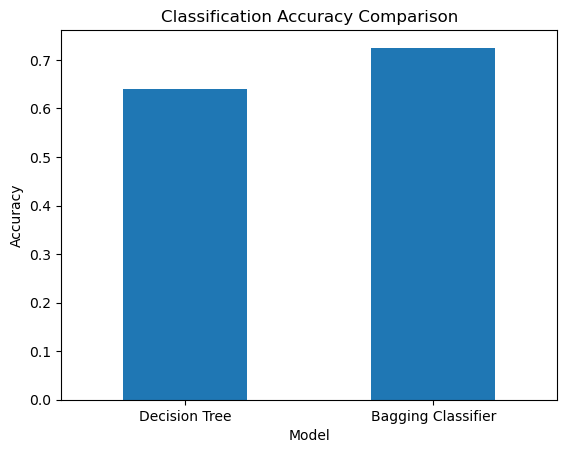

In [32]:
import matplotlib.pyplot as plt

classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Classification Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

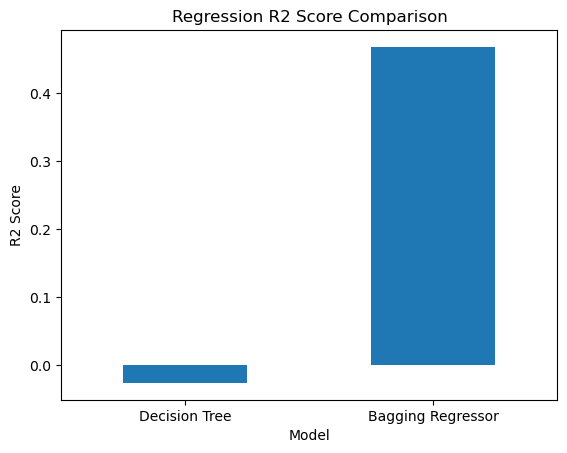

In [33]:
regression_results.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    legend=False
)

plt.title("Regression R2 Score Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()

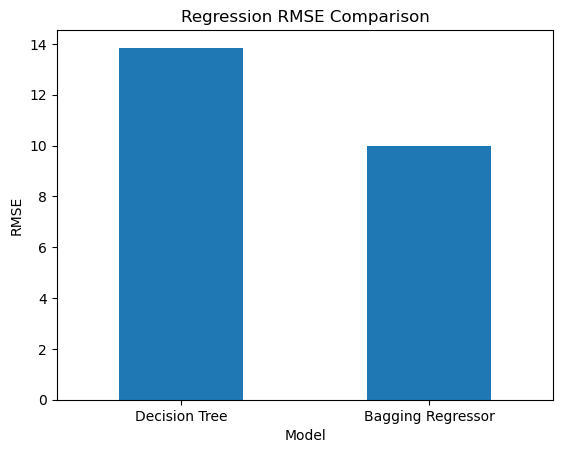

In [34]:
regression_results.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False
)

plt.title("Regression RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

# Part D: Boosting Algorithmsr

### Task 12: AdaBoost Classifier

AdaBoost trains weak learners sequentially.
Each new learner focuses more on the samples that previous learners classified incorrectly.

In [35]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

In [36]:
ada_clf = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_clf.fit(X_train_cls_processed, y_train_cls)

ada_pred = ada_clf.predict(X_test_cls_processed)

In [37]:
print("Accuracy :", accuracy_score(y_test_cls, ada_pred))

print("\nClassification Report\n")
print(classification_report(y_test_cls, ada_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test_cls, ada_pred))

Accuracy : 0.7221153846153846

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       650
           1       0.66      0.55      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.72      0.72      0.72      1040


Confusion Matrix

[[538 112]
 [177 213]]


### Task 13: AdaBoost Regressor

AdaBoost Regressor combines multiple weak regressors to improve prediction accuracy.

In [38]:
ada_reg = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_reg.fit(X_train_reg_processed, y_train_reg)

ada_reg_pred = ada_reg.predict(X_test_reg_processed)

In [39]:
ada_mae = mean_absolute_error(y_test_reg, ada_reg_pred)

ada_rmse = np.sqrt(mean_squared_error(y_test_reg, ada_reg_pred))

ada_r2 = r2_score(y_test_reg, ada_reg_pred)

print("MAE :", ada_mae)
print("RMSE :", ada_rmse)
print("R2 Score :", ada_r2)

MAE : 8.728957420057958
RMSE : 10.724225045680068
R2 Score : 0.3844504845154305


### Task 15: Gradient Boosting Classifier

In [40]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_clf.fit(X_train_cls_processed, y_train_cls)


gb_pred = gb_clf.predict(X_test_cls_processed)

In [41]:
print("Accuracy :", accuracy_score(y_test_cls, gb_pred))

print(classification_report(y_test_cls, gb_pred))

print(confusion_matrix(y_test_cls, gb_pred))

Accuracy : 0.7326923076923076
              precision    recall  f1-score   support

           0       0.76      0.83      0.80       650
           1       0.67      0.57      0.61       390

    accuracy                           0.73      1040
   macro avg       0.72      0.70      0.71      1040
weighted avg       0.73      0.73      0.73      1040

[[540 110]
 [168 222]]


### Task 16: Implement Gradient Boosting Regressor

In [42]:
gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_reg.fit(X_train_reg_processed, y_train_reg)

gb_reg_pred = gb_reg.predict(X_test_reg_processed)

In [43]:
gb_mae = mean_absolute_error(y_test_reg, gb_reg_pred)

gb_rmse = np.sqrt(mean_squared_error(y_test_reg, gb_reg_pred))

gb_r2 = r2_score(y_test_reg, gb_reg_pred)

print("MAE :", gb_mae)
print("RMSE :", gb_rmse)
print("R2 Score :", gb_r2)

MAE : 7.8435579866743295
RMSE : 9.81281314960461
R2 Score : 0.48463109168151897


### Task 17: Analyze Learning Rate & Number of Estimators

In [44]:
results = []

for lr in [0.01, 0.05, 0.1]:
    for est in [50,100,200]:

        model = GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=est,
            random_state=42
        )

        model.fit(X_train_cls_processed, y_train_cls)

        pred = model.predict(X_test_cls_processed)

        acc = accuracy_score(y_test_cls,pred)

        results.append([lr,est,acc])

results = pd.DataFrame(results,
                       columns=["Learning Rate","Estimators","Accuracy"])

results

,Learning Rate,Estimators,Accuracy
0,0.01,50,0.669231
1,0.01,100,0.699038
2,0.01,200,0.728846
3,0.05,50,0.734615
4,0.05,100,0.735577
5,0.05,200,0.735577
6,0.10,50,0.735577
7,0.10,100,0.732692
8,0.10,200,0.720192


Increasing the number of estimators generally improves model accuracy.

A smaller learning rate usually produces better generalization but requires more estimators.

A learning rate of 0.1 with 100 estimators is often a good balance.

In [45]:
from lightgbm import LGBMClassifier

In [46]:
lgb_clf = LGBMClassifier(
    n_estimators=100,
    random_state=42
)

lgb_clf.fit(X_train_cls_processed,y_train_cls)

lgb_pred = lgb_clf.predict(X_test_cls_processed)

[LightGBM] [Info] Number of positive: 1562, number of negative: 2598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1346
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375481 -> initscore=-0.508775
[LightGBM] [Info] Start training from score -0.508775


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [47]:
print("Accuracy :",accuracy_score(y_test_cls,lgb_pred))

print(classification_report(y_test_cls,lgb_pred))

Accuracy : 0.7201923076923077
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       650
           1       0.64      0.57      0.61       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.72      0.72      0.72      1040



### Task 19: Implement LightGBM Regressor

In [48]:
from lightgbm import LGBMRegressor

In [49]:
lgb_reg = LGBMRegressor(
    n_estimators=100,
    random_state=42
)

lgb_reg.fit(X_train_reg_processed,y_train_reg)

lgb_reg_pred = lgb_reg.predict(X_test_reg_processed)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1341
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 37
[LightGBM] [Info] Start training from score 74.774183


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [50]:
lgb_mae = mean_absolute_error(y_test_reg,lgb_reg_pred)

lgb_rmse = np.sqrt(mean_squared_error(y_test_reg,lgb_reg_pred))

lgb_r2 = r2_score(y_test_reg,lgb_reg_pred)

print("MAE :",lgb_mae)

print("RMSE :",lgb_rmse)

print("R2 :",lgb_r2)

MAE : 8.03980246043569
RMSE : 9.987216240717903
R2 : 0.4661489979333894


### Task 20: Performance Analysis

LightGBM trains much faster than traditional Gradient Boosting.

It uses leaf-wise tree growth, making it highly efficient for large datasets while maintaining high accuracy.

In [51]:
from xgboost import XGBClassifier

In [52]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_clf.fit(X_train_cls_processed,y_train_cls)

xgb_pred = xgb_clf.predict(X_test_cls_processed)

In [53]:
print("Accuracy :",accuracy_score(y_test_cls,xgb_pred))

print(classification_report(y_test_cls,xgb_pred))

Accuracy : 0.7163461538461539
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       650
           1       0.64      0.56      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.68      0.69      1040
weighted avg       0.71      0.72      0.71      1040



### Task 22: Implement XGBoost Regressor

In [54]:
from xgboost import XGBRegressor

In [55]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_reg.fit(X_train_reg_processed,y_train_reg)

xgb_reg_pred = xgb_reg.predict(X_test_reg_processed)

In [56]:
xgb_mae = mean_absolute_error(y_test_reg,xgb_reg_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test_reg,xgb_reg_pred))

xgb_r2 = r2_score(y_test_reg,xgb_reg_pred)

print("MAE :",xgb_mae)

print("RMSE :",xgb_rmse)

print("R2 :",xgb_r2)

MAE : 8.200955205330482
RMSE : 10.309186966638391
R2 : 0.4311732810707656


### Task 23: Compare Boosting Algorithms

In [57]:
classification_comparison = pd.DataFrame({

    "Model":[
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test_cls, ada_pred),
        accuracy_score(y_test_cls, gb_pred),
        accuracy_score(y_test_cls, lgb_pred),
        accuracy_score(y_test_cls, xgb_pred)
    ]

})

classification_comparison

,Model,Accuracy
0,AdaBoost,0.722115
1,Gradient Boosting,0.732692
2,LightGBM,0.720192
3,XGBoost,0.716346


In [58]:
regression_comparison = pd.DataFrame({

    "Model":["AdaBoost","Gradient Boosting","LightGBM","XGBoost"],

    "MAE":[ada_mae,gb_mae,lgb_mae,xgb_mae],

    "RMSE":[ada_rmse,gb_rmse,lgb_rmse,xgb_rmse],

    "R2 Score":[ada_r2,gb_r2,lgb_r2,xgb_r2]})

regression_comparison

,Model,MAE,RMSE,R2 Score
0,AdaBoost,8.728957,10.724225,0.384450
1,Gradient Boosting,7.843558,9.812813,0.484631
2,LightGBM,8.039802,9.987216,0.466149
3,XGBoost,8.200955,10.309187,0.431173


# Part E: Advanced Ensemble Learning

### Task 24 : Voting Classifier

Voting combines predictions from multiple machine learning models.

Hard Voting:
Final prediction is based on majority voting.

Soft Voting:
Final prediction is based on average class probabilities.

In [59]:
from sklearn.ensemble import (
    VotingClassifier,
    VotingRegressor,
    StackingClassifier,
    StackingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

In [60]:
voting_clf = VotingClassifier(

    estimators=[

        ("dt", DecisionTreeClassifier(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
        ("gb", GradientBoostingClassifier(random_state=42))

    ],

    voting="hard"
)

voting_clf.fit(X_train_cls_processed, y_train_cls)

vote_pred = voting_clf.predict(X_test_cls_processed)

In [61]:
vote_acc = accuracy_score(y_test_cls, vote_pred)

print("Voting Classifier Accuracy :", vote_acc)

print()

print(classification_report(y_test_cls, vote_pred))

print(confusion_matrix(y_test_cls, vote_pred))

Voting Classifier Accuracy : 0.7259615384615384

              precision    recall  f1-score   support

           0       0.74      0.86      0.80       650
           1       0.68      0.50      0.58       390

    accuracy                           0.73      1040
   macro avg       0.71      0.68      0.69      1040
weighted avg       0.72      0.73      0.72      1040

[[559  91]
 [194 196]]


### Task 25 : Voting Regressor

Voting Regressor predicts by averaging outputs from multiple regression models.

In [62]:
voting_reg = VotingRegressor(

    estimators=[

        ("dt", DecisionTreeRegressor(random_state=42)),
        ("rf", RandomForestRegressor(random_state=42)),
        ("gb", GradientBoostingRegressor(random_state=42))

    ]

)

voting_reg.fit(X_train_reg_processed, y_train_reg)

vote_reg_pred = voting_reg.predict(X_test_reg_processed)

In [63]:
vote_mae = mean_absolute_error(y_test_reg, vote_reg_pred)

vote_rmse = np.sqrt(mean_squared_error(y_test_reg, vote_reg_pred))

vote_r2 = r2_score(y_test_reg, vote_reg_pred)

print("MAE :", vote_mae)

print("RMSE :", vote_rmse)

print("R2 Score :", vote_r2)

MAE : 8.29042213949306
RMSE : 10.378970508091934
R2 Score : 0.42344636891612886


### Task 26 : Stacking Classifier

Stacking combines predictions from multiple base learners.

A meta-model learns from these predictions to improve performance.

In [64]:
from sklearn.linear_model import LogisticRegression, LinearRegression

base_models = [

    ("dt", DecisionTreeClassifier(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))

]

stack_clf = StackingClassifier(

    estimators=base_models,

    final_estimator=LogisticRegression(max_iter=1000)

)

stack_clf.fit(X_train_cls_processed, y_train_cls)

stack_pred = stack_clf.predict(X_test_cls_processed)

In [65]:
stack_acc = accuracy_score(y_test_cls, stack_pred)

print("Stacking Accuracy :", stack_acc)

print()

print(classification_report(y_test_cls, stack_pred))

print()

print(confusion_matrix(y_test_cls, stack_pred))

Stacking Accuracy : 0.7317307692307692

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       650
           1       0.68      0.54      0.60       390

    accuracy                           0.73      1040
   macro avg       0.72      0.69      0.70      1040
weighted avg       0.73      0.73      0.72      1040


[[550 100]
 [179 211]]


### Task 27: Implement Stacking Regressor

In [66]:
base_reg = [

    ("dt", DecisionTreeRegressor(random_state=42)),
    ("rf", RandomForestRegressor(random_state=42)),
    ("gb", GradientBoostingRegressor(random_state=42))

]

stack_reg = StackingRegressor(

    estimators=base_reg,

    final_estimator=LinearRegression()

)

stack_reg.fit(X_train_reg_processed, y_train_reg)

stack_reg_pred = stack_reg.predict(X_test_reg_processed)

In [67]:
stack_mae = mean_absolute_error(y_test_reg, stack_reg_pred)

stack_rmse = np.sqrt(mean_squared_error(y_test_reg, stack_reg_pred))

stack_r2 = r2_score(y_test_reg, stack_reg_pred)

print("MAE :", stack_mae)

print("RMSE :", stack_rmse)

print("R2 Score :", stack_r2)

MAE : 7.820516147353187
RMSE : 9.797210608952831
R2 Score : 0.4862686794976375


In [68]:
classification_results = pd.DataFrame({

    "Model":[

        "Voting Classifier",
        "Stacking Classifier"

    ],

    "Accuracy":[

        vote_acc,
        stack_acc

    ]

})

classification_results

,Model,Accuracy
0,Voting Classifier,0.725962
1,Stacking Classifier,0.731731


In [69]:
regression_results = pd.DataFrame({

    "Model":[

        "Voting Regressor",
        "Stacking Regressor"

    ],

    "MAE":[

        vote_mae,
        stack_mae

    ],

    "RMSE":[

        vote_rmse,
        stack_rmse

    ],

    "R2 Score":[

        vote_r2,
        stack_r2

    ]

})

regression_results

,Model,MAE,RMSE,R2 Score
0,Voting Regressor,8.290422,10.378971,0.423446
1,Stacking Regressor,7.820516,9.797211,0.486269


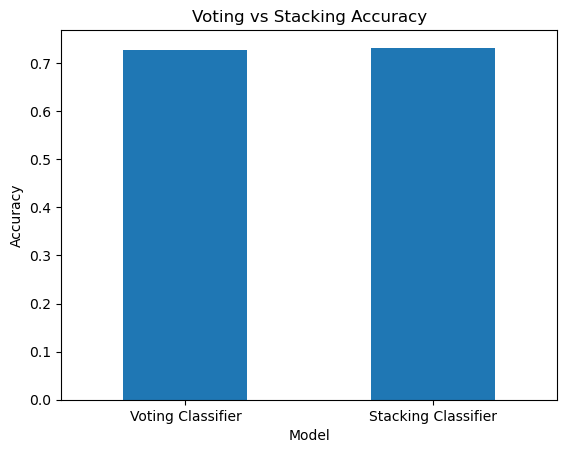

In [70]:
classification_results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Voting vs Stacking Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)

plt.show()

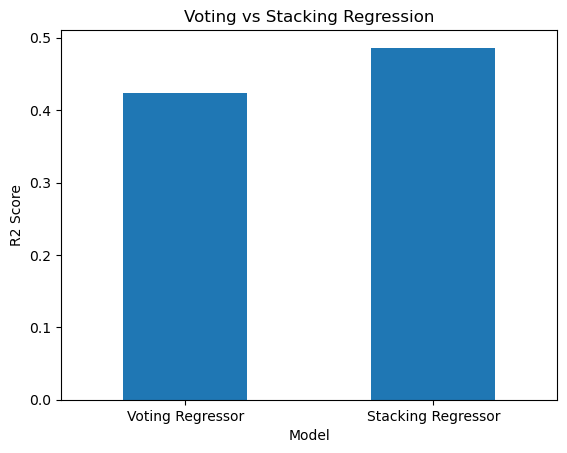

In [71]:
regression_results.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    legend=False
)

plt.title("Voting vs Stacking Regression")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)

plt.show()

# Part F : Model Evaluation and Comparison

### Task 28 : Compare Ensemble Models

Compare the performance of all ensemble models using evaluation metrics.

Classification Metric:
- Accuracy

Regression Metrics:
- MAE
- RMSE
- R² Score

In [72]:
classification_models = pd.DataFrame({

    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost",
        "Voting",
        "Stacking"
    ],

    "Accuracy":[
        bag_accuracy,
        accuracy_score(y_test_cls, ada_pred),
        accuracy_score(y_test_cls, gb_pred),
        accuracy_score(y_test_cls, lgb_pred),
        accuracy_score(y_test_cls, xgb_pred),
        vote_acc,
        stack_acc
    ]

})

classification_models

,Model,Accuracy
0,Bagging,0.725000
1,AdaBoost,0.722115
2,Gradient Boosting,0.732692
3,LightGBM,0.720192
4,XGBoost,0.716346
5,Voting,0.725962
6,Stacking,0.731731


In [73]:
best_cls = classification_models.loc[
    classification_models["Accuracy"].idxmax()
]

print(best_cls)

Model       Gradient Boosting
Accuracy             0.732692
Name: 2, dtype: object


In [74]:
regression_models = pd.DataFrame({

    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "LightGBM",
        "XGBoost",
        "Voting",
        "Stacking"
    ],

    "MAE":[
        bag_mae,
        ada_mae,
        gb_mae,
        lgb_mae,
        xgb_mae,
        vote_mae,
        stack_mae
    ],

    "RMSE":[
        bag_rmse,
        ada_rmse,
        gb_rmse,
        lgb_rmse,
        xgb_rmse,
        vote_rmse,
        stack_rmse
    ],

    "R2 Score":[
        bag_r2,
        ada_r2,
        gb_r2,
        lgb_r2,
        xgb_r2,
        vote_r2,
        stack_r2
    ]

})

regression_models

,Model,MAE,RMSE,R2 Score
0,Bagging,7.987297,9.970812,0.467901
1,AdaBoost,8.728957,10.724225,0.384450
2,Gradient Boosting,7.843558,9.812813,0.484631
3,LightGBM,8.039802,9.987216,0.466149
4,XGBoost,8.200955,10.309187,0.431173
5,Voting,8.290422,10.378971,0.423446
6,Stacking,7.820516,9.797211,0.486269


In [75]:
best_reg = regression_models.loc[
    regression_models["R2 Score"].idxmax()
]

print(best_reg)

Model       Stacking
MAE         7.820516
RMSE        9.797211
R2 Score    0.486269
Name: 6, dtype: object


# task 29 : visualization

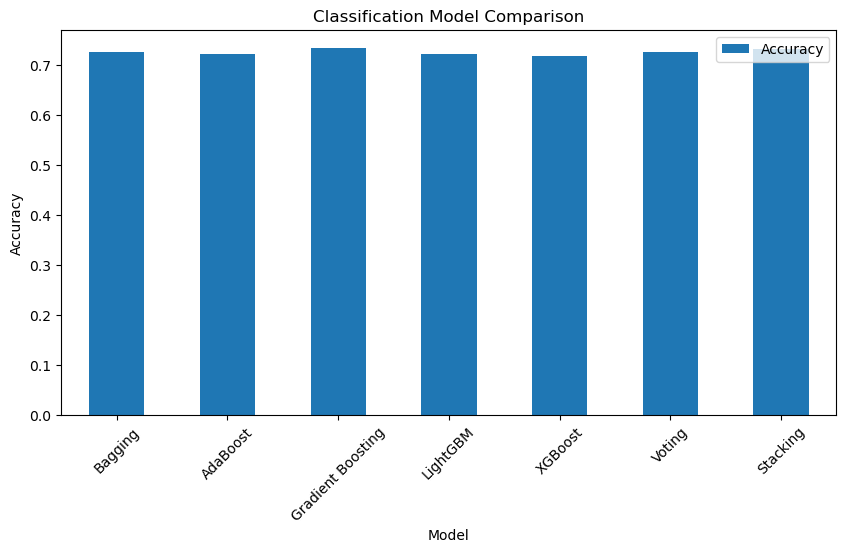

In [77]:
classification_models.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(10,5)
)

plt.title("Classification Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

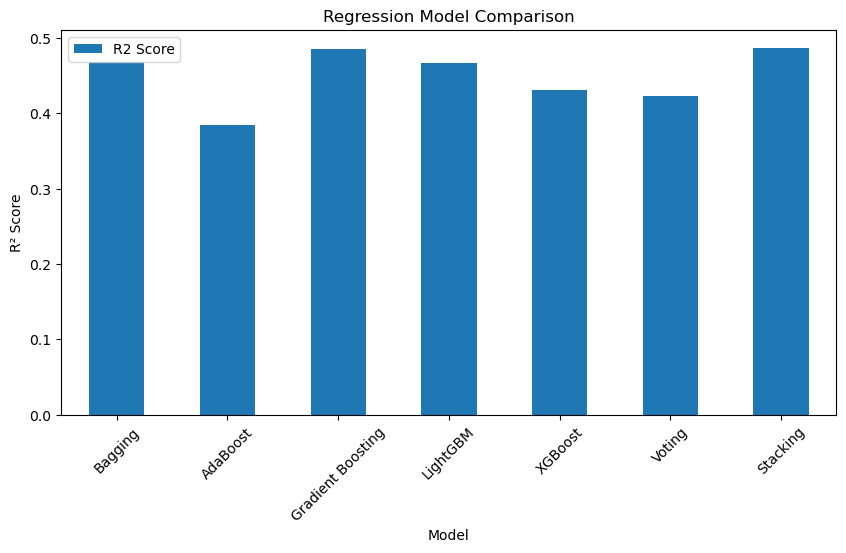

In [78]:
regression_models.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(10,5)
)

plt.title("Regression Model Comparison")

plt.ylabel("R² Score")

plt.xticks(rotation=45)

plt.show()

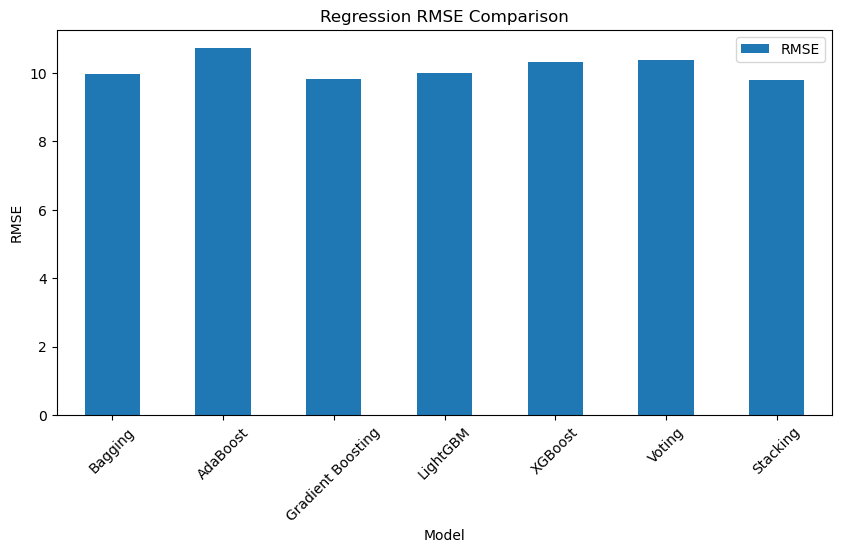

In [79]:
regression_models.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(10,5)
)

plt.title("Regression RMSE Comparison")

plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.show()

## Task 30 : Model Interpretation

In [80]:
print("Best Classification Model")

print(best_cls)

print()

print("Best Regression Model")

print(best_reg)

Best Classification Model
Model       Gradient Boosting
Accuracy             0.732692
Name: 2, dtype: object

Best Regression Model
Model       Stacking
MAE         7.820516
RMSE        9.797211
R2 Score    0.486269
Name: 6, dtype: object


# Part G : Final Analysis

### Task 31 : Final Summary

In [81]:
summary = pd.DataFrame({

    "Task":[

        "Classification",
        "Regression"

    ],

    "Best Model":[

        best_cls["Model"],
        best_reg["Model"]

    ]

})


summary

,Task,Best Model
0,Classification,Gradient Boosting
1,Regression,Stacking


# Task 32 : Final Report

In [82]:
print("="*60)

print("ENSEMBLE LEARNING PROJECT REPORT")

print("="*60)

print()

print("Dataset Successfully Loaded")

print("Data Preprocessing Completed")

print("Bagging Completed")

print("Boosting Completed")

print("Voting Completed")

print("Stacking Completed")

print()

print("Best Classification Model :", best_cls["Model"])

print("Classification Accuracy :", best_cls["Accuracy"])

print()

print("Best Regression Model :", best_reg["Model"])

print("Regression R2 Score :", best_reg["R2 Score"])

print()

print("Project Completed Successfully")

print("="*60)

ENSEMBLE LEARNING PROJECT REPORT

Dataset Successfully Loaded
Data Preprocessing Completed
Bagging Completed
Boosting Completed
Voting Completed
Stacking Completed

Best Classification Model : Gradient Boosting
Classification Accuracy : 0.7326923076923076

Best Regression Model : Stacking
Regression R2 Score : 0.4862686794976375

Project Completed Successfully
